# How do shape moments (Ixx, Iyy, and Ixy) change across visits?
** Run on the RSP or with API access

Script showing how to transform shape moments from the source catalog which are in camera coordinates to ra/dec or alt/az.


Author: Maya Redden, msredden@stanford.edu
last updated: 10/21/2025


In [ ]:
#import general packages
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, join
import astropy.units as u
from scipy.optimize import curve_fit


#import LSST packages
from lsst.rsp import get_tap_service
import lsst.daf.butler as dafButler
from lsst.geom import LinearTransform, radians
from lsst.afw.geom import Quadrupole, Ellipse


#For API Access
from APIaccess import queryTAP


In [27]:
#Use the tap service to get the source and visit catalog data

service = get_tap_service("tap")

ra, dec = 53.1685491, -28.1392568
search_radius = 3 #arcsec

query = f"""SELECT band,
            calibFlux,
            calibFluxErr,
            coord_dec,
            coord_ra,
            dec,
            decErr,
            detector,
            ixx,
            ixxPSF,
            ixy,
            ixyPSF,
            iyy,
            iyyPSF,
            psfFlux,
            psfFluxErr,
            ra,
            raErr,
            visit,
            x,
            y
    FROM dp1.Source 
    WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', {ra}, {dec}, {search_radius/3600}))=1"""

job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
source_table = job.fetch_result().to_table()


visits = source_table['visit']
visit_string = "','".join(map(str, visits))

visit_query = f"""SELECT airmass,altitude,azimuth,band,dec,expTime,ra,skyRotation,visit,zenithDistance,expMidptMJD 
    FROM dp1.Visit 
    WHERE visit IN ('{visit_string}')"""


job = service.submit_job(visit_query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
visit_table = job.fetch_result().to_table()

Job phase is COMPLETED
Job phase is COMPLETED


In [28]:
#check for duplicated visits and remove 

visit_IDs = source_table['visit']

has_duplicates = len(visit_IDs) != len(np.unique(visit_IDs))
print("Any duplicates?", has_duplicates)

vals, counts = np.unique(visit_IDs, return_counts=True)
duplicates = vals[counts > 1]
# print("Duplicated visits:", duplicates)

source_mask = np.isin(source_table['visit'], duplicates)
source_table = source_table[~source_mask]

#create a master table with the source and visit information
master = join(source_table, visit_table, keys = 'visit')

Any duplicates? True


In [29]:
#add a column for the parallactic angle of each observation

from rotateMoments import parallactic_angle_from_radec

# Coordinates of the observatory:
lat = -30.244633 #-30:14:40.68
lon = -70.749417 #-70:44:57.90
height = 2647 


# Add a column for the parallactic angle and the magnitude of the astrometric shift (from a reference position) projected along the zenith direction
master['q'] = np.zeros(len(master))

for i in range(len(master)):
    ra, dec, mjd = master['ra_1', 'dec_1', 'expMidptMJD'][i]
    par = parallactic_angle_from_radec(ra * u.deg, dec * u.deg, mjd, lat * u.deg, lon * u.deg, height * u.m)
    # print(par.value)
    master['q'][i] = par.value
    

In [ ]:
# Aside: you can also access the parallactic angle from the visit images which might be more accurate(?)
# Warning: this takes a long time

'''
from lsst.geom import LinearTransform, radians

boresightParAngles = []
boresightRotAngles = []

for i in range(len(master)):
    visit_image = butler.get("visit_image", visit = master['visit'][i], detector = master['detector'][i])
    visitInfo = visit_image.visitInfo
    boresightParAngles.append(visitInfo.boresightParAngle.asRadians())
    boresightRotAngles.append(visitInfo.boresightRotAngle.asRadians())

master['q'] = boresightParAngles
master['boresightRotAngle'] = boresightRotAngle
'''

In [30]:
# calculate the shape moments in the alt/az and ra/dec coordinate systems

from rotateMoments import rotateXYtoAA, rotateXYtoNW, rotateNWtoAA

# x/y to az/alt (first need to add telescope rotation angle to the master table):
master['rotTelPos'] = master['q'] - master['skyRotation']*np.pi/180 - (np.pi / 2)
aaIxx, aaIyy, aaIxy = rotateXYtoAA(master['ixx'], master['iyy'], master['ixy'], master['rotTelPos'])

master['aaIxx'] = aaIxx
master['aaIyy'] = aaIyy
master['aaIxy'] = aaIxy



# x/y to ra and dec (n/w)
nwIxx, nwIyy, nwIxy = rotateXYtoNW(master['ixx'], master['iyy'], master['ixy'], master['skyRotation']*np.pi/180)

master['nwIxx'] = nwIxx
master['nwIyy'] = nwIyy
master['nwIxy'] = nwIxy



# optional check: ra/dec to az/alt
# aaIxx2, aaIyy2, aaIxy2 = rotateNWtoAA(nwIxx, nwIyy, nwIxy, master['q'])


/home/msredden/notebooks/rotateMoments.py:85: UserWarning: Warning: converting a masked element to nan.
  shape = Quadrupole(Ixx_, Iyy[i], Ixy[i])
/home/msredden/notebooks/rotateMoments.py:122: UserWarning: Warning: converting a masked element to nan.
  shape = Quadrupole(Ixx_, Iyy[i], Ixy[i])


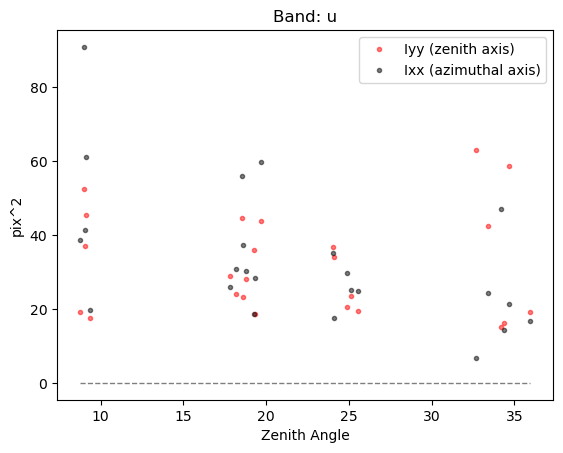

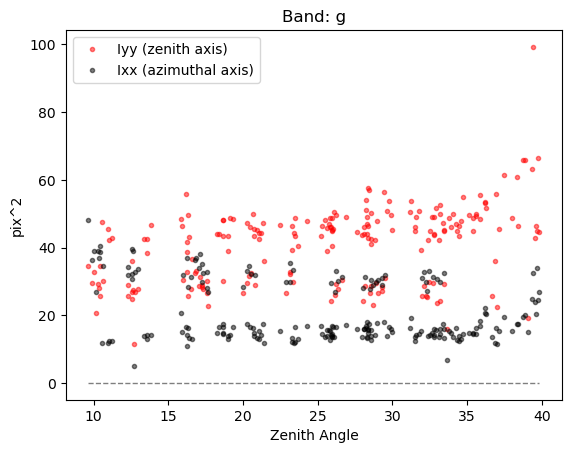

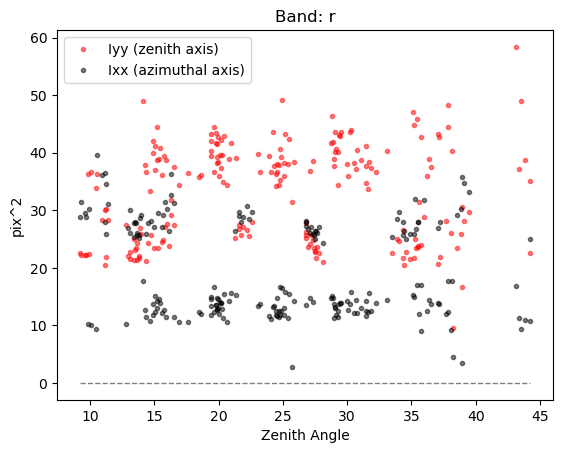

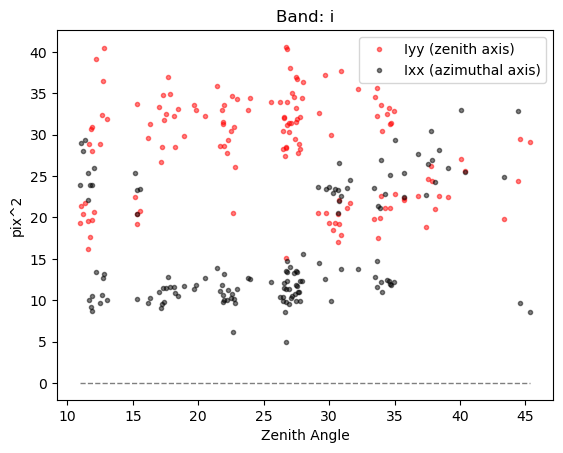

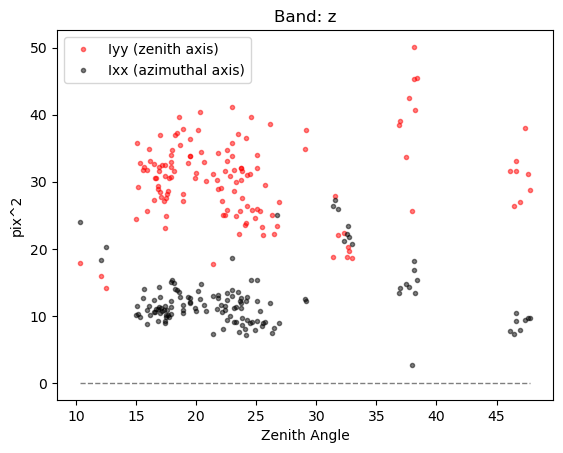

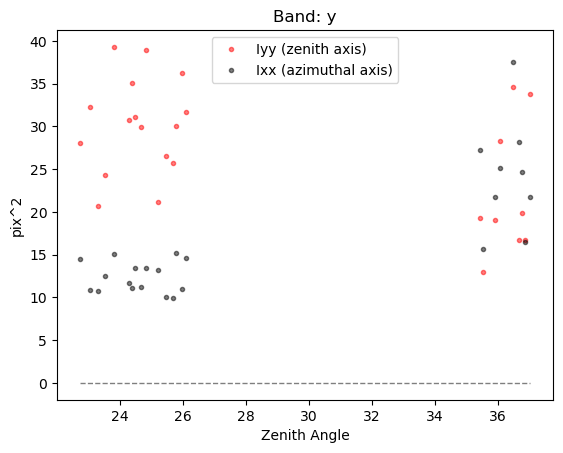

In [32]:
# Plot the moments as a function of zenith angle of the observation 

def dR_model(z, c):
    return c * np.tan(z * np.pi/180)

for band in 'ugrizy':
    band_mask = master['band_1'] == band

    if np.sum(band_mask) > 0:
        airmass = master[band_mask]['airmass']
        z = np.arccos(1 / airmass) * 180 / np.pi
        
        Izz = master['aaIyy'][band_mask]
        Itt = master['aaIxx'][band_mask]
        Izt = master['aaIxy'][band_mask]

        # e1 = (Itt - Izx(Itt + Izz + 2 * np.sqrt(Izz * Itt - Izt**2))

        # popt, pcov = curve_fit(dR_model, z, Izz)

        plt.plot(z, Izz,  ls = '', marker = '.', alpha = 0.5, color = 'r', label = 'Iyy (zenith axis)')
        plt.plot(z, Itt,  ls = '', marker = '.', alpha = 0.5, color = 'k', label = 'Ixx (azimuthal axis)')
        
        z_temp = np.linspace(min(z), max(z), 20) 
        # plt.plot(z_temp, dR_model(z_temp, *popt) , 'k--', linewidth = 2, label = 'Trendline: A tan(z)')
        plt.plot(z_temp, np.zeros(len(z_temp)), 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')
        # plt.plot(zeniths, diff / 3600, 'g.-', label = 'Simulated residual of a 7500 K star (reference: 4000 K star)')
        plt.title(f'Band: {band}')
        plt.xlabel('Zenith Angle')
        plt.ylabel('pix^2')
        plt.legend()
        plt.show()
        plt.close()

